# Imports

In [10]:
# =============================================================================
# Imports and environment setup
# =============================================================================
import os
import sys
import time
import logging
import warnings
from pathlib import Path

warnings.filterwarnings("ignore")

# Make the kernel robust if launched through VSCode/Jupyter rather than
# from an already activated conda shell.
CONDA_PREFIX = Path(sys.executable).resolve().parents[1]

os.environ["CUDA_VISIBLE_DEVICES"] = "0"
os.environ["DGLBACKEND"] = "pytorch"

# Force Linux conda R, not the author's Windows R path.
os.environ["R_HOME"] = str(CONDA_PREFIX / "lib" / "R")
os.environ.pop("R_USER", None)

# Make conda libraries preferred inside Jupyter.
os.environ["LD_LIBRARY_PATH"] = (
    f"{CONDA_PREFIX}/lib:"
    f"{CONDA_PREFIX}/lib/python3.10/site-packages/nvidia/cuda_nvrtc/lib:"
    + os.environ.get("LD_LIBRARY_PATH", "")
)

print("Python:", sys.executable)
print("CONDA_PREFIX:", CONDA_PREFIX)
print("R_HOME:", os.environ["R_HOME"])
print("R_USER:", os.environ.get("R_USER"))

import numpy as np
import pandas as pd
import scanpy as sc
import torch
import yaml
from sklearn.decomposition import PCA
from sklearn import metrics as sk_metrics

import dgl
import torch_geometric
import torch_scatter
import torch_sparse
import torch_cluster

print("torch:", torch.__version__, "cuda:", torch.cuda.is_available(), "torch cuda:", torch.version.cuda)
print("dgl:", dgl.__version__)
print("pyg:", torch_geometric.__version__)
print("scanpy:", sc.__version__)


Python: /work/dal875013/conda_envs/stg3net_env/bin/python
CONDA_PREFIX: /work/dal875013/conda_envs/stg3net_env
R_HOME: /work/dal875013/conda_envs/stg3net_env/lib/R
R_USER: None
torch: 2.2.2+cu118 cuda: True torch cuda: 11.8
dgl: 2.2.1+cu118
pyg: 2.5.2
scanpy: 1.10.1


# USER CONFIGURATION — edit these to match your environment

In [ ]:
# =============================================================================
# USER CONFIGURATION
# =============================================================================

# Path to cloned STG3Net repo
STG3NET_ROOT = Path(r"/work/dal875013/projects/mocha/methods/STG3Net")

# Path to the folder containing SCE_151*.h5ad files
DATA_ROOT = Path(r"/groups/qiwei/mocha/QuickSRT/DLPFC_10x/data")

# Output folder for parquet results
OUTPUT_DIR = Path(r"/work/dal875013/projects/mocha/results/STG3Net/dlpfc_stg3net")

# STG3Net config
CONFIG_PATH = STG3NET_ROOT / "Config" / "Config_DLPFC.yaml"

# Donor-level DLPFC grouping, following the usual 3 donors x 4 slices structure.
DLPFC_DONOR_GROUPS = {
    "donor_1": ["151507", "151508", "151509", "151510"],
    "donor_2": ["151669", "151670", "151671", "151672"],
    "donor_3": ["151673", "151674", "151675", "151676"],
}

# ----- SUBSET SELECTOR -----------------------------------------------------
# First smoke test:
# DONOR_GROUPS_TO_RUN = "donor_3"
#
# Full run:
DONOR_GROUPS_TO_RUN = None
#
# You can also use:
# DONOR_GROUPS_TO_RUN = ["donor_1", "donor_3"]

METHOD_NAME = "STG3Net"
CLUST_METHOD = "mclust"
NUM_RUNS = 1

# DLPFC benchmark uses fixed 7 spatial domains.
FIXED_NUM_CLUSTERS = 7

# Ground-truth label column in adata.obs.
GT_LABEL_COL = "z"


# =============================================================================
# General helpers
# =============================================================================
def setup_logging(output_dir: Path):
    output_dir.mkdir(parents=True, exist_ok=True)
    log_file = output_dir / "benchmark.log"
    logging.basicConfig(
        level=logging.INFO,
        format="%(asctime)s [%(levelname)s] %(message)s",
        handlers=[
            logging.StreamHandler(sys.stdout),
            logging.FileHandler(log_file, mode="w"),
        ],
        force=True,
    )
    logging.info(f"Log file: {log_file}")


def get_device():
    """Return 'cuda:0' if a CUDA GPU is available, else 'cpu'. Logs details."""
    if torch.cuda.is_available():
        dev = "cuda:0"
        os.environ["CUDA_VISIBLE_DEVICES"] = "0"
        logging.info(f"[DEVICE] CUDA available — using {dev}")
        logging.info(f"[DEVICE] GPU name: {torch.cuda.get_device_name(0)}")
        logging.info(
            f"[DEVICE] GPU memory: "
            f"{torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB"
        )
    else:
        dev = "cpu"
        logging.warning("[DEVICE] No CUDA GPU detected — falling back to CPU")
    return dev


def resolve_donor_groups(selector) -> dict:
    """Turn DONOR_GROUPS_TO_RUN into a concrete dict: donor_name -> sample_ids."""
    if selector is None or selector == "all":
        return dict(DLPFC_DONOR_GROUPS)
    if isinstance(selector, str):
        return {selector: DLPFC_DONOR_GROUPS[selector]}
    if isinstance(selector, (list, tuple)):
        return {name: DLPFC_DONOR_GROUPS[name] for name in selector}
    raise ValueError(f"Unrecognized DONOR_GROUPS_TO_RUN value: {selector!r}")


def detect_gt_column(adata) -> str:
    """Auto-detect which obs column holds the ground-truth layer label."""
    if GT_LABEL_COL is not None:
        if GT_LABEL_COL not in adata.obs.columns:
            raise KeyError(
                f"GT_LABEL_COL={GT_LABEL_COL!r} not in adata.obs. "
                f"Available columns: {list(adata.obs.columns)}"
            )
        return GT_LABEL_COL

    candidates = [
        "layer_guess", "layer_guess_reordered", "layer_guess_reordered_short",
        "Ground Truth", "ground_truth", "GroundTruth",
        "layer", "Layer", "annotation", "Annotation", "z",
    ]
    for c in candidates:
        if c in adata.obs.columns:
            return c
    raise KeyError(
        f"Could not auto-detect ground-truth column. "
        f"adata.obs columns: {list(adata.obs.columns)}. "
        f"Please set GT_LABEL_COL manually."
    )


def to_numpy(x):
    """Convert torch tensor / sparse / dense object to numpy array."""
    if hasattr(x, "detach"):
        return x.detach().cpu().numpy()
    if hasattr(x, "data") and hasattr(x.data, "cpu"):
        return x.data.cpu().numpy()
    if hasattr(x, "toarray"):
        return x.toarray()
    return np.asarray(x)


def get_num_clusters() -> int:
    """Return fixed number of DLPFC clusters."""
    return int(FIXED_NUM_CLUSTERS)


def check_mclust_if_needed():
    """Fail early if mclust clustering is requested but unavailable."""
    if CLUST_METHOD != "mclust":
        return
    try:
        import rpy2.robjects.packages as rpackages
        if not rpackages.isinstalled("mclust"):
            raise RuntimeError(
                "R package 'mclust' is not installed in stg3net_env. Run this once:\n"
                "conda install -n stg3net_env -c conda-forge r-mclust -y"
            )
    except Exception as e:
        raise RuntimeError(
            "Cannot verify R package 'mclust'. If you plan to use CLUST_METHOD='mclust', run:\n"
            "conda install -n stg3net_env -c conda-forge r-mclust -y\n"
            f"Original error: {e}"
        )


def patch_stg3net_windows_r_paths():
    """
    Patch the author's hard-coded Windows R paths in STG3Net/Utils.py.

    This is needed on Juno because STG3Net/Utils.py originally contains:
        os.environ['R_HOME'] = 'D:/software/R/R-4.3.2'
        os.environ['R_USER'] = 'D:/software/anaconda/.../rpy2'

    The patch is idempotent and keeps a .bak file.
    """
    utils_path = STG3NET_ROOT / "STG3Net" / "Utils.py"
    if not utils_path.exists():
        raise FileNotFoundError(f"Cannot find {utils_path}")

    text = utils_path.read_text()
    if "D:/software/R/R-4.3.2" not in text and "D:/software/anaconda" not in text:
        logging.info("[PATCH] No Windows R paths detected in STG3Net/Utils.py")
        return

    bak_path = utils_path.with_suffix(".py.bak")
    if not bak_path.exists():
        bak_path.write_text(text)

    if "import sys" not in text:
        text = text.replace("import os\n", "import os\nimport sys\n", 1)

    old = (
        "os.environ['R_HOME'] = 'D:/software/R/R-4.3.2'\n"
        "os.environ['R_USER'] = 'D:/software/anaconda/anaconda3/envs/pt20cu118/Lib/site-packages/rpy2'\n"
    )
    new = (
        "CONDA_PREFIX = os.environ.get('CONDA_PREFIX', os.path.dirname(os.path.dirname(sys.executable)))\n"
        "os.environ['R_HOME'] = os.environ.get('R_HOME', os.path.join(CONDA_PREFIX, 'lib', 'R'))\n"
        "os.environ.pop('R_USER', None)\n"
    )
    if old in text:
        text = text.replace(old, new)
    else:
        # Fallback line-by-line cleanup if whitespace changed.
        lines = []
        for line in text.splitlines():
            if "D:/software/R/R-4.3.2" in line:
                lines.append(
                    "os.environ['R_HOME'] = os.environ.get('R_HOME', os.path.join(CONDA_PREFIX, 'lib', 'R'))"
                )
            elif "D:/software/anaconda" in line:
                lines.append("os.environ.pop('R_USER', None)")
            else:
                lines.append(line)
        text = "\n".join(lines) + "\n"

    utils_path.write_text(text)

    pycache = STG3NET_ROOT / "STG3Net" / "__pycache__"
    if pycache.exists():
        import shutil
        shutil.rmtree(pycache)

    logging.info("[PATCH] Patched STG3Net/Utils.py Windows R paths")


# Data loading  (adapted for .h5ad input)

In [12]:
# =============================================================================
# Data loading  (adapted for .h5ad input)
# =============================================================================
def load_dlpfc_sample(config: dict, sample_id: str, model_mod):
    """
    Load and preprocess one DLPFC .h5ad file using the same style as the
    uploaded SpaCross notebook, but with STG3Net graph construction.

    Returns:
        adata_proc : preprocessed AnnData
        graph_dict : STG3Net graph dictionary
        gt_col     : ground-truth obs column used
    """
    h5ad_path = DATA_ROOT / f"SCE_{sample_id}.h5ad"
    logging.info(f"  [LOAD] Reading {h5ad_path}")
    if not h5ad_path.exists():
        raise FileNotFoundError(f"Missing .h5ad file: {h5ad_path}")

    adata = sc.read_h5ad(h5ad_path)
    adata.var_names_make_unique()

    logging.info(
        f"  [DIAG] Loaded AnnData: n_obs={adata.n_obs}, n_vars={adata.n_vars}"
    )
    logging.info(f"  [DIAG] obs columns: {list(adata.obs.columns)}")
    logging.info(f"  [DIAG] obsm keys  : {list(adata.obsm.keys())}")

    # ---- Ground-truth label column ----
    gt_col = detect_gt_column(adata)
    adata.obs["layer_guess"] = adata.obs[gt_col].astype(object)
    n_labeled = adata.obs["layer_guess"].notna().sum()
    logging.info(
        f"  [DIAG] Using GT column '{gt_col}'  "
        f"(labeled spots: {n_labeled}/{adata.n_obs})"
    )

    # ---- STG3Net metadata, matching author's DLPFC notebook conventions ----
    adata.obs["batch_name"] = sample_id
    adata.obs["slice_id"] = 0
    adata.obs["proj_name"] = sample_id

    # This DLPFC .h5ad uses obsm['S'] as spatial coordinates.
    # STG3Net graph_construction expects spatial coordinates in adata.obsm.
    if "spatial" not in adata.obsm:
        if "S" in adata.obsm:
            adata.obsm["spatial"] = np.asarray(adata.obsm["S"])
            logging.info("  [DIAG] Aliased obsm['S'] -> obsm['spatial']")
        else:
            raise KeyError(
                f"No spatial coordinates found in {h5ad_path}. "
                f"Available obsm keys: {list(adata.obsm.keys())}"
            )
    logging.info(f"  [DIAG] spatial coords shape: {adata.obsm['spatial'].shape}")

    # ---- Build spatial graph before gene filtering, matching STG3Net tutorial ----
    k = config["data"]["k_cutoff"]
    graph_dict = model_mod.graph_construction(adata, k)
    logging.info(f"  [DIAG] Built STG3Net graph_dict with k={k}")

    # ---- Preprocessing: same as uploaded SpaCross notebook / STG3Net tutorial ----
    if hasattr(adata.X, "toarray"):
        adata.layers["count"] = adata.X.toarray()
    else:
        adata.layers["count"] = np.asarray(adata.X).copy()

    sc.pp.filter_genes(adata, min_cells=50)
    sc.pp.filter_genes(adata, min_counts=10)
    logging.info(f"  [DIAG] After gene filtering: n_vars={adata.n_vars}")

    sc.pp.normalize_total(adata, target_sum=1e6)
    sc.pp.highly_variable_genes(
        adata,
        flavor="seurat_v3",
        layer="count",
        n_top_genes=config["data"]["top_genes"],
    )
    adata = adata[:, adata.var["highly_variable"]].copy()
    sc.pp.scale(adata)

    logging.info(
        f"  [DIAG] After HVG selection: n_vars={adata.n_vars} "
        f"(target top_genes={config['data']['top_genes']})"
    )

    n_pcs = max(1, min(200, adata.n_vars, adata.n_obs - 1))
    adata.obsm["X_pca"] = PCA(n_components=n_pcs, random_state=42).fit_transform(
        np.asarray(adata.X)
    )
    logging.info(f"  [DIAG] PCA done: X_pca shape={adata.obsm['X_pca'].shape}")

    return adata, graph_dict, gt_col


# Donor-level data loading

In [13]:
# =============================================================================
# Donor-level data loading
# =============================================================================
def load_one_dlpfc_slice_for_stg3net(
    sample_id: str,
    slice_id: int,
    config_data: dict,
    model_mod,
):
    """
    Load one DLPFC .h5ad slice and build its STG3Net graph before concatenation.
    This follows the author's Run_DLPFC.ipynb logic, but reads your SCE_*.h5ad files.
    """
    h5ad_path = DATA_ROOT / f"SCE_{sample_id}.h5ad"
    logging.info(f"    [LOAD] Reading {h5ad_path}")
    if not h5ad_path.exists():
        raise FileNotFoundError(f"Missing .h5ad file: {h5ad_path}")

    adata_tmp = sc.read_h5ad(h5ad_path)
    adata_tmp.var_names_make_unique()

    logging.info(
        f"    [DIAG] {sample_id}: n_obs={adata_tmp.n_obs}, n_vars={adata_tmp.n_vars}"
    )
    logging.info(f"    [DIAG] {sample_id}: obs columns={list(adata_tmp.obs.columns)}")
    logging.info(f"    [DIAG] {sample_id}: obsm keys={list(adata_tmp.obsm.keys())}")

    gt_col = detect_gt_column(adata_tmp)
    adata_tmp.obs["layer_guess"] = adata_tmp.obs[gt_col].astype(object)
    adata_tmp.obs["batch_name"] = sample_id
    adata_tmp.obs["slice_id"] = int(slice_id)
    adata_tmp.obs["proj_name"] = sample_id
    adata_tmp.obs["sample"] = sample_id
    adata_tmp.obs["original_spot_id"] = adata_tmp.obs_names.astype(str)

    n_labeled = int(adata_tmp.obs["layer_guess"].notna().sum())
    logging.info(
        f"    [DIAG] {sample_id}: using GT column '{gt_col}' "
        f"(labeled spots: {n_labeled}/{adata_tmp.n_obs})"
    )

    if "spatial" not in adata_tmp.obsm:
        if "S" in adata_tmp.obsm:
            adata_tmp.obsm["spatial"] = np.asarray(adata_tmp.obsm["S"])
            logging.info(f"    [DIAG] {sample_id}: aliased obsm['S'] -> obsm['spatial']")
        else:
            raise KeyError(
                f"No spatial coordinates found in {h5ad_path}. "
                f"Available obsm keys: {list(adata_tmp.obsm.keys())}"
            )

    k = int(config_data["k_cutoff"])
    graph_dict_tmp = model_mod.graph_construction(adata_tmp, k)
    logging.info(f"    [DIAG] {sample_id}: built STG3Net graph_dict with k={k}")

    return adata_tmp, graph_dict_tmp, gt_col


def load_dlpfc_donor_group(
    donor_name: str,
    sample_ids: list,
    config: dict,
    model_mod,
):
    """
    Load and concatenate 4 DLPFC slices for one donor, matching STG3Net's
    multi-slice input design.

    Returns:
        adata      : concatenated and preprocessed AnnData
        graph_dict : combined STG3Net graph dictionary
        gt_cols    : dict sample_id -> original GT column
    """
    logging.info(f"  [DONOR] Loading {donor_name}: {sample_ids}")

    adata = None
    graph_dict = None
    gt_cols = {}

    for slice_idx, sample_id in enumerate(sample_ids):
        adata_tmp, graph_dict_tmp, gt_col = load_one_dlpfc_slice_for_stg3net(
            sample_id=sample_id,
            slice_id=slice_idx,
            config_data=config["data"],
            model_mod=model_mod,
        )
        gt_cols[sample_id] = gt_col

        if adata is None:
            adata = adata_tmp
            graph_dict = graph_dict_tmp
        else:
            # Match the author's Run_DLPFC.ipynb logic: intersect genes before concatenation.
            var_names = adata.var_names.intersection(adata_tmp.var_names)
            adata = adata[:, var_names].copy()
            adata_tmp = adata_tmp[:, var_names].copy()

            # AnnData.concatenate keeps obsm arrays and makes obs_names unique.
            adata = adata.concatenate(adata_tmp)
            graph_dict = model_mod.combine_graph_dict(graph_dict, graph_dict_tmp)

    logging.info(
        f"  [DIAG] Combined {donor_name}: n_obs={adata.n_obs}, n_vars={adata.n_vars}, "
        f"batches={adata.obs['batch_name'].astype(str).unique().tolist()}"
    )

    # Preprocessing after concatenation. This mirrors the author's tutorial but
    # avoids making a dense count layer before gene filtering.
    sc.pp.filter_genes(adata, min_cells=50)
    sc.pp.filter_genes(adata, min_counts=10)
    logging.info(f"  [DIAG] {donor_name}: after gene filtering n_vars={adata.n_vars}")

    # Store raw counts for Seurat v3 HVG before normalization.
    adata.layers["count"] = adata.X.copy()

    sc.pp.normalize_total(adata, target_sum=1e6)
    sc.pp.highly_variable_genes(
        adata,
        flavor="seurat_v3",
        layer="count",
        n_top_genes=config["data"]["top_genes"],
    )
    adata = adata[:, adata.var["highly_variable"]].copy()
    sc.pp.scale(adata)

    logging.info(
        f"  [DIAG] {donor_name}: after HVG selection n_vars={adata.n_vars} "
        f"(target top_genes={config['data']['top_genes']})"
    )

    n_pcs = max(1, min(200, adata.n_vars, adata.n_obs - 1))
    X_for_pca = adata.X.toarray() if hasattr(adata.X, "toarray") else np.asarray(adata.X)
    adata.obsm["X_pca"] = PCA(n_components=n_pcs, random_state=42).fit_transform(X_for_pca)
    logging.info(f"  [DIAG] {donor_name}: PCA done, X_pca shape={adata.obsm['X_pca'].shape}")

    return adata, graph_dict, gt_cols


# Metrics and donor-level training

In [14]:
# =============================================================================
# Metrics
# =============================================================================
def compute_stg3net_metrics(model_mod, sub_adata, gt_key: str, pred_key: str):
    """
    Compute the same output fields used by the SpaCross benchmark:
    ARI, NMI, ACC, DIS.

    ACC follows the SpaCross-style aggregation:
        mean(NMI, HOM, COM)
    DIS follows:
        mean(CHAOS, PAS)
    """
    y_true = sub_adata.obs[gt_key].astype(str).to_numpy()
    y_pred = sub_adata.obs[pred_key].astype(str).to_numpy()

    try:
        ARI = float(model_mod.compute_ARI(sub_adata, gt_key, pred_key))
    except Exception:
        ARI = float(sk_metrics.adjusted_rand_score(y_true, y_pred))

    try:
        NMI = float(model_mod.compute_NMI(sub_adata, gt_key, pred_key))
    except Exception:
        NMI = float(sk_metrics.normalized_mutual_info_score(y_true, y_pred))

    try:
        HOM = float(model_mod.compute_HOM(sub_adata, gt_key, pred_key))
    except Exception:
        HOM = float(sk_metrics.homogeneity_score(y_true, y_pred))

    try:
        COM = float(model_mod.compute_COM(sub_adata, gt_key, pred_key))
    except Exception:
        COM = float(sk_metrics.completeness_score(y_true, y_pred))

    ACC = float(np.nanmean([NMI, HOM, COM]))

    try:
        CHAOS = float(model_mod.compute_CHAOS(sub_adata, pred_key))
    except Exception as e:
        logging.warning(f"  [WARN] compute_CHAOS failed: {e}")
        CHAOS = np.nan

    try:
        PAS = float(model_mod.compute_PAS(sub_adata, pred_key))
    except Exception as e:
        logging.warning(f"  [WARN] compute_PAS failed: {e}")
        PAS = np.nan

    DIS = float(np.nanmean([CHAOS, PAS])) if not np.all(np.isnan([CHAOS, PAS])) else np.nan

    return ARI, NMI, ACC, DIS, HOM, COM, CHAOS, PAS


# =============================================================================
# Train one donor group and return slice-level metrics
# =============================================================================
def train_one_donor_group(
    donor_name: str,
    sample_ids: list,
    adata,
    graph_dict,
    config: dict,
    device: str,
    model_mod,
    clust_method: str = "mclust",
    run_seed: int = 0,
):
    """
    Train STG3Net once on one donor group (4 slices), then compute metrics
    separately for each slice.

    Returns:
        metrics_list: list of per-slice metric dicts
        pred_df     : DataFrame with SpaCross-compatible prediction columns
    """
    num_clusters = get_num_clusters()
    logging.info(
        f"  [TRAIN] Starting STG3Net | donor={donor_name} | "
        f"slices={sample_ids} | k_clusters={num_clusters} | "
        f"device={device} | run_seed={run_seed}"
    )

    t0 = time.time()

    np.random.seed(run_seed)
    torch.manual_seed(run_seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(run_seed)

    net = model_mod.G3net(
        adata,
        graph_dict=graph_dict,
        device=device,
        config=config,
        num_cluster=num_clusters,
    )

    net.train(verbose=1)

    enc_rep, recon = net.process()
    enc_rep = to_numpy(enc_rep)
    recon = to_numpy(recon)
    adata.obsm["latent"] = enc_rep
    adata.obsm["recon"] = recon

    logging.info(
        f"  [DIAG] {donor_name}: latent shape={enc_rep.shape}, recon shape={recon.shape}"
    )

    adata = net.clustering(
        adata,
        num_cluster=num_clusters,
        used_obsm="latent",
        key_added_pred=clust_method,
        method=clust_method,
        random_seed=666 + run_seed,
    )

    pred_labels = adata.obs[clust_method].astype(str).to_numpy()
    logging.info(
        f"  [DIAG] {donor_name}: cluster sizes="
        f"{pd.Series(pred_labels).astype(str).value_counts().to_dict()}"
    )

    elapsed = time.time() - t0
    gpu_name = torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU"

    metrics_list = []
    pred_frames = []

    # Slice-level metrics and predictions.
    for sample_id in sample_ids:
        mask = adata.obs["batch_name"].astype(str).to_numpy() == str(sample_id)
        slice_adata = adata[mask].copy()
        labeled_slice = slice_adata[~pd.isnull(slice_adata.obs["layer_guess"])].copy()

        ARI, NMI, ACC, DIS, HOM, COM, CHAOS, PAS = compute_stg3net_metrics(
            model_mod, labeled_slice, "layer_guess", clust_method
        )

        metrics = {
            "method": METHOD_NAME,
            "sample": sample_id,
            "run_seed": run_seed,
            "ARI": float(ARI),
            "NMI": float(NMI),
            "ACC": float(ACC),
            "DIS": float(DIS) if not pd.isna(DIS) else np.nan,
            # Allocate group runtime across its slices so sum(running_time_sec)
            # approximates the actual donor-level training time.
            "running_time_sec": round(elapsed / max(1, len(sample_ids)), 2),
            "gpu_model": gpu_name,
            "training_unit": donor_name,
            "training_samples": ",".join(sample_ids),
            "donor_running_time_sec": round(elapsed, 2),
            "num_clusters": int(num_clusters),
            "num_spots": int(slice_adata.n_obs),
            "num_labeled_spots": int(labeled_slice.n_obs),
            "num_training_spots": int(adata.n_obs),
            "num_genes_after_hvg": int(adata.n_vars),
            "clust_method": clust_method,
            "device": device,
            "HOM": float(HOM),
            "COM": float(COM),
            "CHAOS": float(CHAOS) if not pd.isna(CHAOS) else np.nan,
            "PAS": float(PAS) if not pd.isna(PAS) else np.nan,
        }
        metrics_list.append(metrics)

        logging.info(
            f"  [METRICS] {donor_name}/{sample_id}: "
            f"ARI={ARI:.4f}  NMI={NMI:.4f}  ACC={ACC:.4f}  "
            f"DIS={DIS:.4f}  allocated_time={elapsed / len(sample_ids):.1f}s  "
            f"donor_time={elapsed:.1f}s  gpu={gpu_name}"
        )

        spot_ids = (
            slice_adata.obs["original_spot_id"].astype(str).to_numpy()
            if "original_spot_id" in slice_adata.obs.columns
            else slice_adata.obs_names.astype(str).to_numpy()
        )

        pred_frames.append(
            pd.DataFrame(
                {
                    "method": METHOD_NAME,
                    "sample": sample_id,
                    "run_seed": run_seed,
                    "spot_id": spot_ids,
                    "true_label": slice_adata.obs["layer_guess"].astype(object).to_numpy(),
                    "pred_label": np.asarray(slice_adata.obs[clust_method]).astype(str),
                }
            )
        )

    pred_df = pd.concat(pred_frames, ignore_index=True)

    del net
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    return metrics_list, pred_df


# Main benchmark loop

In [15]:
# =============================================================================
# Main benchmark loop
# =============================================================================
def run_benchmark():
    setup_logging(OUTPUT_DIR)

    logging.info("=" * 72)
    logging.info("STG3Net DLPFC Donor-Level Benchmarking Framework")
    logging.info("=" * 72)

    if not STG3NET_ROOT.exists():
        raise FileNotFoundError(
            f"STG3NET_ROOT not found: {STG3NET_ROOT.resolve()}\n"
            f"Clone it with: git clone https://github.com/wenwenmin/STG3Net.git"
        )

    # Patch author hard-coded Windows R paths before importing STG3Net.
    patch_stg3net_windows_r_paths()

    sys.path.insert(0, str(STG3NET_ROOT.resolve()))
    import STG3Net as MODEL  # noqa: N814

    check_mclust_if_needed()
    device = get_device()

    if not DATA_ROOT.exists():
        raise FileNotFoundError(f"DATA_ROOT not found: {DATA_ROOT.resolve()}")

    logging.info(f"[PATHS] STG3NET_ROOT = {STG3NET_ROOT.resolve()}")
    logging.info(f"[PATHS] DATA_ROOT    = {DATA_ROOT.resolve()}")
    logging.info(f"[PATHS] OUTPUT_DIR   = {OUTPUT_DIR.resolve()}")

    if not CONFIG_PATH.exists():
        raise FileNotFoundError(f"CONFIG_PATH not found: {CONFIG_PATH.resolve()}")
    with open(CONFIG_PATH, "r", encoding="utf-8") as f:
        config = yaml.safe_load(f)
    logging.info(f"[CONFIG] {config}")

    donor_groups = resolve_donor_groups(DONOR_GROUPS_TO_RUN)
    logging.info(f"[DONORS] Will process {len(donor_groups)} donor group(s): {donor_groups}")
    logging.info(f"[SETTINGS] clust_method={CLUST_METHOD}  num_runs={NUM_RUNS}")
    logging.info("[MODE] donor-level multi-slice training; slice-level metrics/output")

    all_metrics = []
    all_predictions = []
    failed = []

    for i, (donor_name, sample_ids) in enumerate(donor_groups.items(), start=1):
        logging.info("")
        logging.info("-" * 72)
        logging.info(f"[{i}/{len(donor_groups)}] Donor group {donor_name}: {sample_ids}")
        logging.info("-" * 72)

        try:
            adata, graph_dict, gt_cols = load_dlpfc_donor_group(
                donor_name=donor_name,
                sample_ids=sample_ids,
                config=config,
                model_mod=MODEL,
            )

            for run in range(NUM_RUNS):
                logging.info(f"  -> Run {run + 1}/{NUM_RUNS}")
                adata_run = adata.copy()

                metrics_list, pred_df = train_one_donor_group(
                    donor_name=donor_name,
                    sample_ids=sample_ids,
                    adata=adata_run,
                    graph_dict=graph_dict,
                    config=config,
                    device=device,
                    model_mod=MODEL,
                    clust_method=CLUST_METHOD,
                    run_seed=run,
                )

                for row in metrics_list:
                    row["gt_col"] = gt_cols.get(row["sample"], GT_LABEL_COL)
                all_metrics.extend(metrics_list)
                all_predictions.append(pred_df)

            if torch.cuda.is_available():
                torch.cuda.empty_cache()

        except Exception as e:
            logging.exception(f"[FAILED] Donor group {donor_name}: {e}")
            failed.append({"training_unit": donor_name, "error": str(e)})
            continue

    if not all_metrics:
        logging.error("No successful runs — nothing to save.")
        return

    predictions = pd.concat(all_predictions, ignore_index=True)
    performance = pd.DataFrame(all_metrics)

    perf_lead = [
        "method", "sample", "run_seed",
        "ARI", "NMI", "ACC", "DIS",
        "running_time_sec", "gpu_model",
        "training_unit", "training_samples", "donor_running_time_sec",
    ]
    performance = performance[
        perf_lead + [c for c in performance.columns if c not in perf_lead]
    ]

    # Keep prediction file exactly SpaCross-compatible.
    pred_lead = ["method", "sample", "run_seed", "spot_id", "true_label", "pred_label"]
    predictions = predictions[pred_lead]

    pred_path = OUTPUT_DIR / "predictions.parquet"
    perf_path = OUTPUT_DIR / "performance.parquet"
    predictions.to_parquet(pred_path, index=False)
    performance.to_parquet(perf_path, index=False)

    logging.info("")
    logging.info("=" * 72)
    logging.info("SAVED")
    logging.info("=" * 72)
    logging.info(f"  predictions.parquet -> {pred_path}  ({len(predictions):,} rows)")
    logging.info(f"  performance.parquet -> {perf_path}  ({len(performance):,} rows)")

    logging.info("")
    logging.info("Per-slice metrics:")
    show_cols = [
        "training_unit", "sample", "ARI", "NMI", "ACC", "DIS",
        "running_time_sec", "donor_running_time_sec",
    ]
    logging.info("\n" + performance[show_cols].to_string(index=False))

    logging.info("")
    logging.info(
        f"Overall mean ARI: {performance['ARI'].mean():.4f}  "
        f"NMI: {performance['NMI'].mean():.4f}  "
        f"ACC: {performance['ACC'].mean():.4f}  "
        f"DIS: {performance['DIS'].mean():.4f}"
    )
    logging.info(f"GPU model(s) used: {sorted(performance['gpu_model'].unique().tolist())}")
    logging.info(f"Total donor-level running time: {performance[['training_unit', 'run_seed', 'donor_running_time_sec']].drop_duplicates()['donor_running_time_sec'].sum():.1f}s")

    if failed:
        logging.warning(f"\n{len(failed)} donor group(s) failed:")
        for f_ in failed:
            logging.warning(f"  - {f_['training_unit']}: {f_['error']}")

    logging.info("\nBenchmarking complete.")


# Execute the benchmark when this cell is run.
run_benchmark()


2026-05-11 20:56:07,363 [INFO] Log file: /work/dal875013/projects/mocha/results/dlpfc_stg3net/benchmark.log


2026-05-11 20:56:07,364 [INFO] ========================================================================
2026-05-11 20:56:07,365 [INFO] STG3Net DLPFC Donor-Level Benchmarking Framework
2026-05-11 20:56:07,366 [INFO] ========================================================================
2026-05-11 20:56:07,370 [INFO] [PATCH] No Windows R paths detected in STG3Net/Utils.py
2026-05-11 20:56:07,468 [INFO] [DEVICE] CUDA available — using cuda:0
2026-05-11 20:56:07,469 [INFO] [DEVICE] GPU name: NVIDIA A30
2026-05-11 20:56:07,470 [INFO] [DEVICE] GPU memory: 25.22 GB
2026-05-11 20:56:07,474 [INFO] [PATHS] STG3NET_ROOT = /work/dal875013/projects/mocha/methods/STG3Net
2026-05-11 20:56:07,475 [INFO] [PATHS] DATA_ROOT    = /groups/qiwei/mocha/QuickSRT/DLPFC_10x/data
2026-05-11 20:56:07,476 [INFO] [PATHS] OUTPUT_DIR   = /work/dal875013/projects/mocha/results/dlpfc_stg3net
2026-05-11 20:56:07,480 [INFO] [CONFIG] {'data': {'dataset': 'DLPFC', 'k_cutoff': 12, 'top_genes': 2000}, 'mode': 'clustering',

Epoch 495 total loss=0.762 recon loss=0.903 tri loss=0.000 disc loss=1.298:  50%|█████     | 500/1000 [00:19<00:18, 27.35it/s]

fitting ...
  |======================================================================| 100%


Epoch 495 total loss=0.762 recon loss=0.903 tri loss=0.000 disc loss=1.298:  50%|█████     | 500/1000 [00:31<00:18, 27.35it/s]

...

Epoch 945 total loss=0.902 recon loss=0.763 tri loss=0.230 disc loss=1.384:  95%|█████████▍| 949/1000 [03:13<00:02, 23.61it/s]

Processing datasets 151675 have 68128 nodes or edges
Processing datasets 151676 have 64723 nodes or edges


Epoch 980 total loss=0.887 recon loss=0.756 tri loss=0.221 disc loss=1.371:  98%|█████████▊| 980/1000 [03:16<00:04,  4.98it/s]

Stop trainning because of loss convergence
2026-05-11 21:09:49,200 [INFO]   [DIAG] donor_3: latent shape=(14364, 16), recon shape=(14364, 200)


fitting ...
  |======================================================================| 100%
2026-05-11 21:09:57,648 [INFO]   [DIAG] donor_3: cluster sizes={'2': 2968, '6': 2635, '7': 2522, '4': 2311, '1': 1889, '5': 1196, '3': 843}
2026-05-11 21:09:58,535 [INFO]   [METRICS] donor_3/151673: ARI=0.5709  NMI=0.7217  ACC=0.7219  DIS=0.0509  allocated_time=51.3s  donor_time=205.3s  gpu=NVIDIA A30
2026-05-11 21:09:59,451 [INFO]   [METRICS] donor_3/151674: ARI=0.6025  NMI=0.7353  ACC=0.7354  DIS=0.0447  allocated_time=51.3s  donor_time=205.3s  gpu=NVIDIA A30
2026-05-11 21:10:00,480 [INFO]   [METRICS] donor_3/151675: ARI=0.5764  NMI=0.7214  ACC=0.7214  DIS=0.0522  allocated_time=51.3s  donor_time=205.3s  gpu=NVIDIA A30
2026-05-11 21:10:01,291 [INFO]   [METRICS] donor_3/151676: ARI=0.5517  NMI=0.6989  ACC=0.6990  DIS=0.0551  allocated_time=51.3s  donor_time=205.3s  gpu=NVIDIA A30
2026-05-11 21:10:01,363 [INFO] 
2026-05-11 21:10:01,364 [INFO] =====================================================

# Prediction results visualization

... storing 'true_label' as categorical
... storing 'pred_label' as categorical


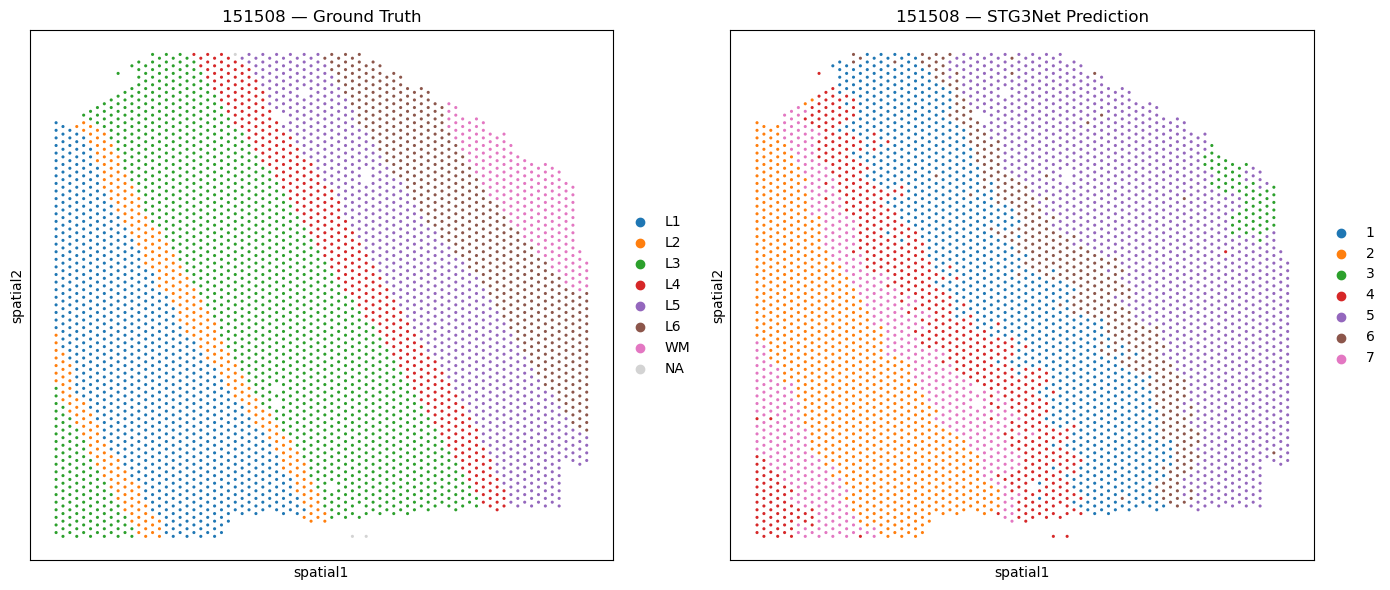

In [ ]:
import pandas as pd
import numpy as np
import scanpy as sc
import matplotlib.pyplot as plt
from pathlib import Path

DATA_ROOT  = Path(r"/groups/qiwei/mocha/QuickSRT/DLPFC_10x/data")
OUTPUT_DIR = Path(r"/work/dal875013/projects/mocha/results/STG3Net/dlpfc_stg3net")

SAMPLE_ID = "151508"

predictions = pd.read_parquet(OUTPUT_DIR / "predictions.parquet")
pred_slice = predictions[predictions["sample"] == SAMPLE_ID].set_index("spot_id")
adata = sc.read_h5ad(DATA_ROOT / f"SCE_{SAMPLE_ID}.h5ad")

adata.obs["true_label"] = pred_slice["true_label"].reindex(adata.obs_names).values
adata.obs["pred_label"] = pred_slice["pred_label"].reindex(adata.obs_names).values

if "spatial" not in adata.obsm:
    adata.obsm["spatial"] = np.asarray(adata.obsm["S"])

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
sc.pl.embedding(
    adata, basis="spatial", color="true_label",
    ax=axes[0], show=False, title=f"{SAMPLE_ID} — Ground Truth", s=20,
)
sc.pl.embedding(
    adata, basis="spatial", color="pred_label",
    ax=axes[1], show=False, title=f"{SAMPLE_ID} — STG3Net Prediction", s=20,
)
axes[0].invert_yaxis()
axes[1].invert_yaxis()
plt.tight_layout()
plt.show()


# Running results summary

In [ ]:
import pandas as pd
from pathlib import Path

OUTPUT_DIR = Path(r"/work/dal875013/projects/mocha/results/STG3Net/dlpfc_stg3net")
perf_path = OUTPUT_DIR / "performance.parquet"

if not perf_path.exists():
    raise FileNotFoundError(f"Cannot find {perf_path}")

performance = pd.read_parquet(perf_path)
performance = performance.sort_values(["training_unit", "sample", "run_seed"]).reset_index(drop=True)

display_cols = [
    "training_unit", "sample", "run_seed",
    "ARI", "NMI", "ACC", "DIS",
    "num_clusters", "num_spots", "num_labeled_spots",
    "running_time_sec", "donor_running_time_sec",
    "clust_method", "gpu_model",
]
display_cols = [c for c in display_cols if c in performance.columns]

print("===== All STG3Net donor-level DLPFC results =====")
display(performance[display_cols])

print("\n===== Summary =====")
summary = performance[["ARI", "NMI", "ACC", "DIS", "running_time_sec"]].describe()
display(summary)

print("\n===== Mean metrics =====")
print(f"Mean ARI: {performance['ARI'].mean():.4f}")
print(f"Mean NMI: {performance['NMI'].mean():.4f}")
print(f"Mean ACC: {performance['ACC'].mean():.4f}")
print(f"Mean DIS: {performance['DIS'].mean():.4f}")

print("\n===== Donor-level runtime =====")
runtime = performance[["training_unit", "run_seed", "donor_running_time_sec"]].drop_duplicates()
display(runtime)
print(f"Total donor-level runtime: {runtime['donor_running_time_sec'].sum():.2f} sec")

print("\n===== Best / worst ARI =====")
best = performance.loc[performance["ARI"].idxmax()]
worst = performance.loc[performance["ARI"].idxmin()]

print(f"Best ARI : {best['sample']} ({best['training_unit']})  ARI={best['ARI']:.4f}")
print(f"Worst ARI: {worst['sample']} ({worst['training_unit']})  ARI={worst['ARI']:.4f}")


===== All STG3Net donor-level DLPFC results =====


,training_unit,sample,run_seed,ARI,NMI,ACC,DIS,num_clusters,num_spots,num_labeled_spots,running_time_sec,donor_running_time_sec,clust_method,gpu_model
0,donor_1,151507,0,0.498567,0.670958,0.671155,0.055091,7,4226,4221,81.73,326.91,mclust,NVIDIA A30
1,donor_1,151508,0,0.503828,0.654666,0.654682,0.057478,7,4384,4381,81.73,326.91,mclust,NVIDIA A30
2,donor_1,151509,0,0.547950,0.679214,0.681048,0.058963,7,4789,4788,81.73,326.91,mclust,NVIDIA A30
3,donor_1,151510,0,0.528664,0.671428,0.673286,0.062114,7,4634,4595,81.73,326.91,mclust,NVIDIA A30
4,donor_2,151669,0,0.334250,0.568916,0.577799,0.068490,7,3661,3636,60.47,241.89,mclust,NVIDIA A30
5,donor_2,151670,0,0.318706,0.547377,0.560597,0.071656,7,3498,3484,60.47,241.89,mclust,NVIDIA A30
6,donor_2,151671,0,0.467155,0.630203,0.637235,0.054124,7,4110,4093,60.47,241.89,mclust,NVIDIA A30
7,donor_2,151672,0,0.509887,0.646059,0.649973,0.062101,7,4015,3888,60.47,241.89,mclust,NVIDIA A30
8,donor_3,151673,0,0.570885,0.721737,0.721871,0.050865,7,3639,3611,51.33,205.32,mclust,NVIDIA A30
9,donor_3,151674,0,0.602509,0.735324,0.735374,0.044733,7,3673,3635,51.33,205.32,mclust,NVIDIA A30



===== Summary =====


,ARI,NMI,ACC,DIS,running_time_sec
count,12.000000,12.000000,12.000000,12.000000,12.000000
mean,0.500876,0.662185,0.665283,0.057747,64.510000
std,0.089793,0.058329,0.054349,0.007525,13.301571
min,0.318706,0.547377,0.560597,0.044733,51.330000
25%,0.490714,0.642095,0.646788,0.053646,51.330000
50%,0.519276,0.671193,0.672221,0.056306,60.470000
75%,0.556467,0.704555,0.704579,0.062105,81.730000
max,0.602509,0.735324,0.735374,0.071656,81.730000



===== Mean metrics =====
Mean ARI: 0.5009
Mean NMI: 0.6622
Mean ACC: 0.6653
Mean DIS: 0.0577

===== Donor-level runtime =====


,training_unit,run_seed,donor_running_time_sec
0,donor_1,0,326.91
4,donor_2,0,241.89
8,donor_3,0,205.32


Total donor-level runtime: 774.12 sec

===== Best / worst ARI =====
Best ARI : 151674 (donor_3)  ARI=0.6025
Worst ARI: 151670 (donor_2)  ARI=0.3187
